In [1]:
import ee
import geemap
import pandas as pd

ee.Initialize()

In [2]:
counties = ee.FeatureCollection("FAO/GAUL/2015/level2")

makueni = counties.filter(
    ee.Filter.And(
        ee.Filter.eq("ADM0_NAME", "Kenya"),
        ee.Filter.eq("ADM2_NAME", "Makueni")
    )
)

In [3]:
months = pd.date_range(
    start="2023-01-01",
    end="2024-12-01",
    freq="MS"
)

months

DatetimeIndex(['2023-01-01', '2023-02-01', '2023-03-01', '2023-04-01',
               '2023-05-01', '2023-06-01', '2023-07-01', '2023-08-01',
               '2023-09-01', '2023-10-01', '2023-11-01', '2023-12-01',
               '2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[us]', freq='MS')

In [4]:
def monthly_mean_ndvi(start_date, end_date):
    
    s2 = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(makueni)
        .filterDate(start_date, end_date)
        .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", 20))
    )
    
    image = s2.median().clip(makueni)

    ndvi = image.normalizedDifference(
        ["B8", "B4"]
    ).rename("NDVI")
    
    mean_ndvi = ndvi.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=makueni.geometry(),
        scale=10,
        maxPixels=1e9
    )

    return mean_ndvi.get("NDVI")

In [5]:
print(
    monthly_mean_ndvi(
        "2024-01-01",
        "2024-02-01"
    ).getInfo()
)

0.6316708595939607


In [6]:
results = []

for start in months:
    end = start + pd.DateOffset(months=1)

    value = monthly_mean_ndvi(
        start.strftime("%Y-%m-%d"),
        end.strftime("%Y-%m-%d")
    ).getInfo()

    results.append({
        "month": start.strftime("%Y-%m"),
        "mean_ndvi": value
    })

    print(start.strftime("%Y-%m"), value)

2023-01 0.4834040774316303
2023-02 0.3265209298887462
2023-03 0.2822371424163942
2023-04 0.4208427219154237
2023-05 0.3027046854339886
2023-06 0.4598421468523512
2023-07 0.26531138036975926
2023-08 0.2738601227054581
2023-09 0.23866367506427918
2023-10 0.22548479281907605
2023-11 0.5111804608515003
2023-12 0.6016234918647538
2024-01 0.6316708595939607
2024-02 0.4560241691070921
2024-03 0.4992027341387732
2024-04 0.5157201569743661
2024-05 0.5632098201938239
2024-06 0.5129601198200868
2024-07 0.26366817468888676
2024-08 0.22031487609077788
2024-09 0.2973616540004048
2024-10 0.27695634234689864
2024-11 0.27100302667160453
2024-12 0.5767439411602133


In [7]:
df = pd.DataFrame(results)
df

,month,mean_ndvi
0,2023-01,0.483404
1,2023-02,0.326521
2,2023-03,0.282237
3,2023-04,0.420843
4,2023-05,0.302705
5,2023-06,0.459842
6,2023-07,0.265311
7,2023-08,0.273860
8,2023-09,0.238664
9,2023-10,0.225485


<Axes: title={'center': 'Monthly Mean NDVI - Makueni County'}, xlabel='month'>

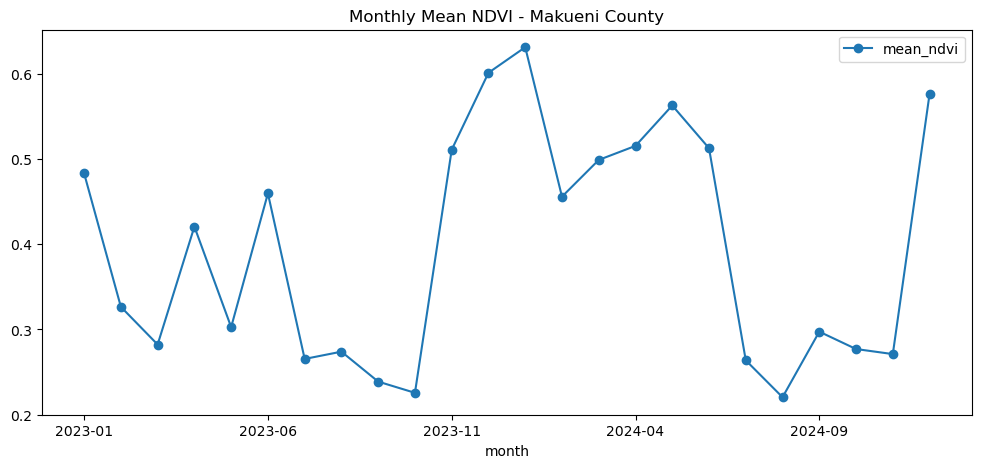

In [8]:
df.plot(
    x="month",
    y="mean_ndvi",
    marker="o",
    figsize=(12, 5),
    title="Monthly Mean NDVI - Makueni County"
)

In [9]:
df["month"] = pd.to_datetime(df["month"])

In [10]:
df.to_csv("../outputs/makueni_monthly_ndvi_2023_2024.csv", index=False)

In [11]:
df.head()

,month,mean_ndvi
0,2023-01-01,0.483404
1,2023-02-01,0.326521
2,2023-03-01,0.282237
3,2023-04-01,0.420843
4,2023-05-01,0.302705


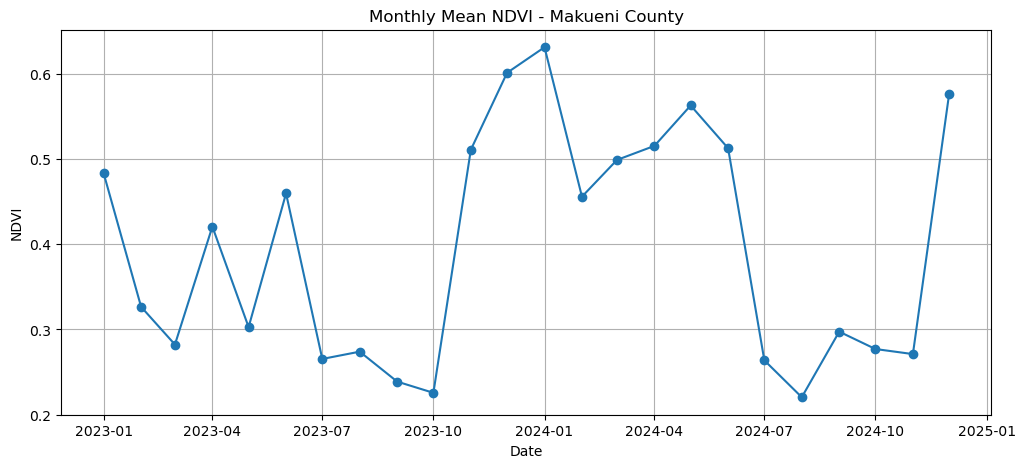

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["month"], df["mean_ndvi"], marker="o")
plt.title("Monthly Mean NDVI - Makueni County")
plt.ylabel("NDVI")
plt.xlabel("Date")
plt.grid(True)

plt.savefig(
    "../docs/images/makueni_ndvi_timeseries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()